**Cell 1: setup and data download**

In [1]:
import os, numpy as np, scipy.io, torch, torch.nn as nn, matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)
dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(dev, torch.__version__)

URL = 'https://github.com/maziarraissi/PINNs/raw/master/main/Data/cylinder_nektar_wake.mat'
if not os.path.exists('cylinder_nektar_wake.mat'):
    !wget -q -O cylinder_nektar_wake.mat {URL}
print(os.path.getsize('cylinder_nektar_wake.mat'), 'bytes')

cuda 2.11.0+cu130
24081984 bytes


**Cell 2: load and inspect**

In [2]:
d = scipy.io.loadmat('cylinder_nektar_wake.mat')
print([k for k in d if not k.startswith('__')])
for k in d:
    if not k.startswith('__'): print(k, d[k].shape)

U = d['U_star']   # (N, 2, T): u and v
P = d['p_star']   # (N, T)
t = d['t']        # (T, 1)
X = d['X_star']   # (N, 2): x, y
print('x range', X[:,0].min(), X[:,0].max())
print('y range', X[:,1].min(), X[:,1].max())
print('t range', t.min(), t.max())
print('u range', U[:,0].min(), U[:,0].max(), '| v range', U[:,1].min(), U[:,1].max())
print('p range', P.min(), P.max())

['X_star', 't', 'U_star', 'p_star']
X_star (5000, 2)
t (200, 1)
U_star (5000, 2, 200)
p_star (5000, 200)
x range 1.0 8.0
y range -2.0 2.0
t range 0.0 19.900000000000002
u range -0.24026849014902615 1.322556473239624 | v range -0.624110517662326 0.6234357373114737
p range -0.5364756020446917 0.07247393407656716


**Cell 3: build the training set**

In [3]:
N, T = X_star_n, T_n = 5000, 200   # placeholder line, replaced below

In [4]:
N, T = X.shape[0], t.shape[0]

# Flatten to one row per (point, snapshot): columns x, y, t, u, v, p
x_all = np.tile(X[:, 0:1], (1, T)).reshape(-1, 1)    # (N*T, 1)
y_all = np.tile(X[:, 1:2], (1, T)).reshape(-1, 1)
t_all = np.tile(t.T, (N, 1)).reshape(-1, 1)
u_all = U[:, 0, :].reshape(-1, 1)
v_all = U[:, 1, :].reshape(-1, 1)
p_all = P.reshape(-1, 1)
print('flattened:', x_all.shape)

# Random training subset (velocity only; p is never used for training)
N_TRAIN = 5000
rng = np.random.default_rng(0)
idx = rng.choice(N*T, N_TRAIN, replace=False)

def to_t(a): return torch.tensor(a, dtype=torch.float32, device=dev)
x_tr, y_tr, t_tr = to_t(x_all[idx]), to_t(y_all[idx]), to_t(t_all[idx])
u_tr, v_tr = to_t(u_all[idx]), to_t(v_all[idx])

print('train pts:', N_TRAIN, f'({100*N_TRAIN/(N*T):.2f}% of the data)')
print('train u mean/std:', u_tr.mean().item(), u_tr.std().item())
print('train v mean/std:', v_tr.mean().item(), v_tr.std().item())

flattened: (1000000, 1)
train pts: 5000 (0.50% of the data)
train u mean/std: 0.8599973320960999 0.28394076228141785
train v mean/std: 0.005673642735928297 0.2718622386455536


**Cell 4: model and residuals**

In [5]:
# Full-data stats for comparison with the training subset
print('full u mean/std:', u_all.mean(), u_all.std())
print('full v mean/std:', v_all.mean(), v_all.std())

lb = torch.tensor([1.0, -2.0, 0.0], device=dev)    # lower bounds of (x, y, t)
ub = torch.tensor([8.0,  2.0, 19.9], device=dev)   # upper bounds

class InvNS(nn.Module):
    def __init__(self, hidden=20, layers=8):
        super().__init__()
        dims = [3] + [hidden]*layers + [2]          # (x,y,t) -> (psi, p)
        self.lins = nn.ModuleList([nn.Linear(a, b) for a, b in zip(dims[:-1], dims[1:])])
        for l in self.lins: nn.init.xavier_normal_(l.weight); nn.init.zeros_(l.bias)
        self.lam1 = nn.Parameter(torch.zeros(1))    # convection coeff (true 1)
        self.lam2 = nn.Parameter(torch.zeros(1))    # viscosity coeff (true 0.01)
    def forward(self, x, y, t):
        h = 2*(torch.cat([x, y, t], 1) - lb)/(ub - lb) - 1   # scale to [-1, 1]
        for l in self.lins[:-1]: h = torch.tanh(l(h))
        return self.lins[-1](h)

def g(f, z):   # df/dz, zeros if f does not depend on z
    r = torch.autograd.grad(f, z, torch.ones_like(f), create_graph=True, allow_unused=True)[0]
    return torch.zeros_like(f) if r is None else r

def fields(model, x, y, t):
    """Returns u, v, p and the two momentum residuals f_u, f_v."""
    x = x.clone().requires_grad_(True)
    y = y.clone().requires_grad_(True)
    t = t.clone().requires_grad_(True)
    out = model(x, y, t); psi, p = out[:, 0:1], out[:, 1:2]
    u = g(psi, y); v = -g(psi, x)                   # continuity holds exactly
    u_t, u_x, u_y = g(u, t), g(u, x), g(u, y)
    v_t, v_x, v_y = g(v, t), g(v, x), g(v, y)
    u_xx, u_yy = g(u_x, x), g(u_y, y)
    v_xx, v_yy = g(v_x, x), g(v_y, y)
    p_x, p_y = g(p, x), g(p, y)
    l1, l2 = model.lam1, model.lam2
    f_u = u_t + l1*(u*u_x + v*u_y) + p_x - l2*(u_xx + u_yy)
    f_v = v_t + l1*(u*v_x + v*v_y) + p_y - l2*(v_xx + v_yy)
    return u, v, p, f_u, f_v

model = InvNS().to(dev)
print('params:', sum(q.numel() for q in model.parameters()))

u, v, p, f_u, f_v = fields(model, x_tr, y_tr, t_tr)
print('shapes:', u.shape, v.shape, p.shape, f_u.shape, f_v.shape)
print('untrained u mean/std:', u.mean().item(), u.std().item())
print('untrained residual MS: f_u', (f_u**2).mean().item(), '| f_v', (f_v**2).mean().item())
print('lam1, lam2:', model.lam1.item(), model.lam2.item())

full u mean/std: 0.8602218826086216 0.28369631009053686
full v mean/std: 0.004339857798824967 0.27413348979226293
params: 3064
shapes: torch.Size([5000, 1]) torch.Size([5000, 1]) torch.Size([5000, 1]) torch.Size([5000, 1]) torch.Size([5000, 1])
untrained u mean/std: -0.02625790424644947 0.025464484468102455
untrained residual MS: f_u 0.00020937883527949452 | f_v 0.010093864053487778
lam1, lam2: 0.0 0.0


**Cell 5: training**

In [6]:
def losses(model):
    u, v, p, f_u, f_v = fields(model, x_tr, y_tr, t_tr)
    l_data = ((u - u_tr)**2).mean() + ((v - v_tr)**2).mean()
    l_pde  = (f_u**2).mean() + (f_v**2).mean()
    return l_data, l_pde

hist = {'step': [], 'loss': [], 'data': [], 'pde': [], 'lam1': [], 'lam2': []}
W_DATA, W_PDE = 1.0, 1.0

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
sched = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9997)

import time; t0 = time.time()
for step in range(10001):
    opt.zero_grad()
    l_data, l_pde = losses(model)
    loss = W_DATA*l_data + W_PDE*l_pde
    loss.backward()
    opt.step(); sched.step()
    if step % 100 == 0:
        hist['step'].append(step); hist['loss'].append(loss.item())
        hist['data'].append(l_data.item()); hist['pde'].append(l_pde.item())
        hist['lam1'].append(model.lam1.item()); hist['lam2'].append(model.lam2.item())
    if step % 1000 == 0:
        print(f'{step:6d} loss {loss.item():.3e} data {l_data.item():.3e} '
              f'pde {l_pde.item():.3e} lam1 {model.lam1.item():.4f} '
              f'lam2 {model.lam2.item():.5f} ({time.time()-t0:.0f}s)')

     0 loss 9.471e-01 data 9.368e-01 pde 1.030e-02 lam1 0.0010 lam2 0.00100 (0s)
  1000 loss 9.228e-02 data 9.223e-02 pde 4.278e-05 lam1 -0.0164 lam2 -0.00105 (96s)
  2000 loss 8.928e-02 data 8.895e-02 pde 3.357e-04 lam1 0.0772 lam2 0.00053 (191s)
  3000 loss 4.502e-02 data 4.033e-02 pde 4.680e-03 lam1 0.8338 lam2 0.01454 (285s)
  4000 loss 1.556e-02 data 1.131e-02 pde 4.248e-03 lam1 0.8930 lam2 0.01638 (379s)
  5000 loss 1.157e-02 data 8.132e-03 pde 3.438e-03 lam1 0.9205 lam2 0.01862 (474s)
  6000 loss 9.150e-03 data 6.422e-03 pde 2.728e-03 lam1 0.9400 lam2 0.01942 (568s)
  7000 loss 7.490e-03 data 5.229e-03 pde 2.262e-03 lam1 0.9534 lam2 0.01874 (663s)
  8000 loss 6.264e-03 data 4.278e-03 pde 1.986e-03 lam1 0.9604 lam2 0.01745 (759s)
  9000 loss 5.356e-03 data 3.583e-03 pde 1.773e-03 lam1 0.9656 lam2 0.01640 (854s)
 10000 loss 4.723e-03 data 3.109e-03 pde 1.615e-03 lam1 0.9694 lam2 0.01560 (949s)


**Cell 6: validation on held-out snapshots, plus a weights backup**

In [7]:
torch.save(model.state_dict(), 'pinn_cylinder_adam.pt')

def rel_l2(a, b): return (np.linalg.norm(a-b) / np.linalg.norm(b)).item()

def validate(model, snaps=(20, 60, 100, 140, 180)):
    rows = []
    for k in snaps:
        xs = to_t(X[:, 0:1]); ys = to_t(X[:, 1:2]); ts = to_t(np.full((N, 1), t[k, 0]))
        u, v, p, _, _ = fields(model, xs, ys, ts)
        u, v, p = [a.detach().cpu().numpy() for a in (u, v, p)]
        u_ref, v_ref, p_ref = U[:, 0, k:k+1], U[:, 1, k:k+1], P[:, k:k+1]
        rows.append((k, rel_l2(u, u_ref), rel_l2(v, v_ref),
                     rel_l2(p - p.mean(), p_ref - p_ref.mean())))
    for k, eu, ev, ep in rows:
        print(f'snapshot {k:3d} (t={t[k,0]:.1f}): relL2 u {eu:.4f}  v {ev:.4f}  p {ep:.4f}')
    print('mean:', *[f'{np.mean([r[i] for r in rows]):.4f}' for i in (1, 2, 3)])

validate(model)
print('lam1 err %.2f%%, lam2 err %.2f%%' %
      (100*abs(model.lam1.item()-1)/1, 100*abs(model.lam2.item()-0.01)/0.01))

snapshot  20 (t=2.0): relL2 u 0.0392  v 0.1261  p 0.2346
snapshot  60 (t=6.0): relL2 u 0.0392  v 0.1818  p 0.2254
snapshot 100 (t=10.0): relL2 u 0.0452  v 0.1644  p 0.2140
snapshot 140 (t=14.0): relL2 u 0.0345  v 0.1408  p 0.2063
snapshot 180 (t=18.0): relL2 u 0.0376  v 0.1460  p 0.2082
mean: 0.0392 0.1518 0.2177
lam1 err 3.06%, lam2 err 55.99%


**Cell 7: L-BFGS in float64**

In [8]:
import copy
DT = torch.float64
m64 = copy.deepcopy(model).double()
x_tr, y_tr, t_tr, u_tr, v_tr = [a.double() for a in (x_tr, y_tr, t_tr, u_tr, v_tr)]
def to_t(a): return torch.tensor(a, dtype=DT, device=dev)

hist_lb = {'loss': [], 'lam1': [], 'lam2': []}
opt_lb = torch.optim.LBFGS(m64.parameters(), lr=1.0, max_iter=500, history_size=50,
                           tolerance_grad=1e-12, tolerance_change=1e-14,
                           line_search_fn='strong_wolfe')
def closure():
    opt_lb.zero_grad()
    l_data, l_pde = losses(m64)
    loss = W_DATA*l_data + W_PDE*l_pde
    loss.backward()
    hist_lb['loss'].append(loss.item())
    hist_lb['lam1'].append(m64.lam1.item()); hist_lb['lam2'].append(m64.lam2.item())
    n = len(hist_lb['loss'])
    if n % 100 == 1:
        print(f'call {n:4d} loss {loss.item():.3e} data {l_data.item():.3e} '
              f'pde {l_pde.item():.3e} lam1 {m64.lam1.item():.4f} lam2 {m64.lam2.item():.5f}')
    return loss

t0 = time.time()
opt_lb.step(closure)
print(f'closure calls: {len(hist_lb["loss"])}, time {time.time()-t0:.0f}s')
print(f'final loss {hist_lb["loss"][-1]:.3e}')
torch.save(m64.state_dict(), 'pinn_cylinder_lbfgs.pt')

validate(m64)
print('lam1 err %.2f%%, lam2 err %.2f%%' %
      (100*abs(m64.lam1.item()-1), 100*abs(m64.lam2.item()-0.01)/0.01))

call    1 loss 4.723e-03 data 3.108e-03 pde 1.615e-03 lam1 0.9694 lam2 0.01560
call  101 loss 3.885e-03 data 2.374e-03 pde 1.511e-03 lam1 0.9779 lam2 0.01295
call  201 loss 3.341e-03 data 2.017e-03 pde 1.324e-03 lam1 0.9781 lam2 0.01336
call  301 loss 2.887e-03 data 1.704e-03 pde 1.183e-03 lam1 0.9820 lam2 0.01319
call  401 loss 2.539e-03 data 1.452e-03 pde 1.087e-03 lam1 0.9860 lam2 0.01263
call  501 loss 2.226e-03 data 1.246e-03 pde 9.806e-04 lam1 0.9845 lam2 0.01220
closure calls: 539, time 77s
final loss 2.131e-03
snapshot  20 (t=2.0): relL2 u 0.0291  v 0.0844  p 0.1330
snapshot  60 (t=6.0): relL2 u 0.0268  v 0.0985  p 0.1258
snapshot 100 (t=10.0): relL2 u 0.0275  v 0.0892  p 0.1341
snapshot 140 (t=14.0): relL2 u 0.0232  v 0.0813  p 0.1480
snapshot 180 (t=18.0): relL2 u 0.0266  v 0.0732  p 0.1875
mean: 0.0267 0.0853 0.1457
lam1 err 1.69%, lam2 err 22.58%


**Cell 8: two more L-BFGS rounds**

In [9]:
for r in range(2):
    n0 = len(hist_lb['loss'])
    opt_lb.step(closure)
    print(f'--- round {r+1}: {len(hist_lb["loss"])-n0} calls, loss {hist_lb["loss"][-1]:.3e}, '
          f'lam1 {m64.lam1.item():.4f}, lam2 {m64.lam2.item():.5f}')
torch.save(m64.state_dict(), 'pinn_cylinder_lbfgs2.pt')

validate(m64)
print('lam1 err %.2f%%, lam2 err %.2f%%' %
      (100*abs(m64.lam1.item()-1), 100*abs(m64.lam2.item()-0.01)/0.01))

call  601 loss 1.998e-03 data 1.102e-03 pde 8.966e-04 lam1 0.9841 lam2 0.01160
call  701 loss 1.804e-03 data 9.522e-04 pde 8.515e-04 lam1 0.9828 lam2 0.01153
call  801 loss 1.638e-03 data 8.502e-04 pde 7.879e-04 lam1 0.9868 lam2 0.01145
call  901 loss 1.501e-03 data 7.610e-04 pde 7.397e-04 lam1 0.9866 lam2 0.01096
call 1001 loss 1.379e-03 data 6.834e-04 pde 6.951e-04 lam1 0.9875 lam2 0.01120
--- round 1: 532 calls, loss 1.307e-03, lam1 0.9870, lam2 0.01134
call 1101 loss 1.276e-03 data 6.256e-04 pde 6.508e-04 lam1 0.9887 lam2 0.01133
call 1201 loss 1.190e-03 data 5.719e-04 pde 6.182e-04 lam1 0.9880 lam2 0.01146
call 1301 loss 1.107e-03 data 5.308e-04 pde 5.762e-04 lam1 0.9903 lam2 0.01121
call 1401 loss 1.032e-03 data 4.825e-04 pde 5.495e-04 lam1 0.9894 lam2 0.01131
call 1501 loss 9.661e-04 data 4.494e-04 pde 5.167e-04 lam1 0.9908 lam2 0.01111
call 1601 loss 9.082e-04 data 4.257e-04 pde 4.825e-04 lam1 0.9908 lam2 0.01113
--- round 2: 549 calls, loss 8.959e-04, lam1 0.9908, lam2 0.01114

**Cell 9: three more L-BFGS rounds**

In [10]:
for r in range(3):
    n0 = len(hist_lb['loss'])
    opt_lb.step(closure)
    print(f'--- round {r+3}: {len(hist_lb["loss"])-n0} calls, loss {hist_lb["loss"][-1]:.3e}, '
          f'lam1 {m64.lam1.item():.4f}, lam2 {m64.lam2.item():.5f}')
torch.save(m64.state_dict(), 'pinn_cylinder_lbfgs5.pt')

validate(m64)
print('lam1 err %.2f%%, lam2 err %.2f%%' %
      (100*abs(m64.lam1.item()-1), 100*abs(m64.lam2.item()-0.01)/0.01))

call 1701 loss 8.622e-04 data 3.968e-04 pde 4.654e-04 lam1 0.9918 lam2 0.01124
call 1801 loss 8.179e-04 data 3.764e-04 pde 4.415e-04 lam1 0.9921 lam2 0.01124
call 1901 loss 7.751e-04 data 3.593e-04 pde 4.158e-04 lam1 0.9904 lam2 0.01112
call 2001 loss 7.343e-04 data 3.381e-04 pde 3.962e-04 lam1 0.9916 lam2 0.01101
call 2101 loss 6.934e-04 data 3.148e-04 pde 3.786e-04 lam1 0.9919 lam2 0.01092
--- round 3: 545 calls, loss 6.738e-04, lam1 0.9925, lam2 0.01097
call 2201 loss 6.631e-04 data 3.016e-04 pde 3.615e-04 lam1 0.9932 lam2 0.01098
call 2301 loss 6.373e-04 data 2.857e-04 pde 3.516e-04 lam1 0.9935 lam2 0.01095
call 2401 loss 6.098e-04 data 2.782e-04 pde 3.316e-04 lam1 0.9931 lam2 0.01099
call 2501 loss 5.839e-04 data 2.632e-04 pde 3.207e-04 lam1 0.9935 lam2 0.01104
call 2601 loss 5.562e-04 data 2.448e-04 pde 3.113e-04 lam1 0.9933 lam2 0.01083
call 2701 loss 5.324e-04 data 2.333e-04 pde 2.991e-04 lam1 0.9940 lam2 0.01078
--- round 4: 541 calls, loss 5.313e-04, lam1 0.9938, lam2 0.01084

**Cell 10: PINN vs reference and error maps**

u: max abs err 1.092e-01, rel L2 0.0125
v: max abs err 4.135e-02, rel L2 0.0320
p: max abs err 3.723e-02, rel L2 0.0537


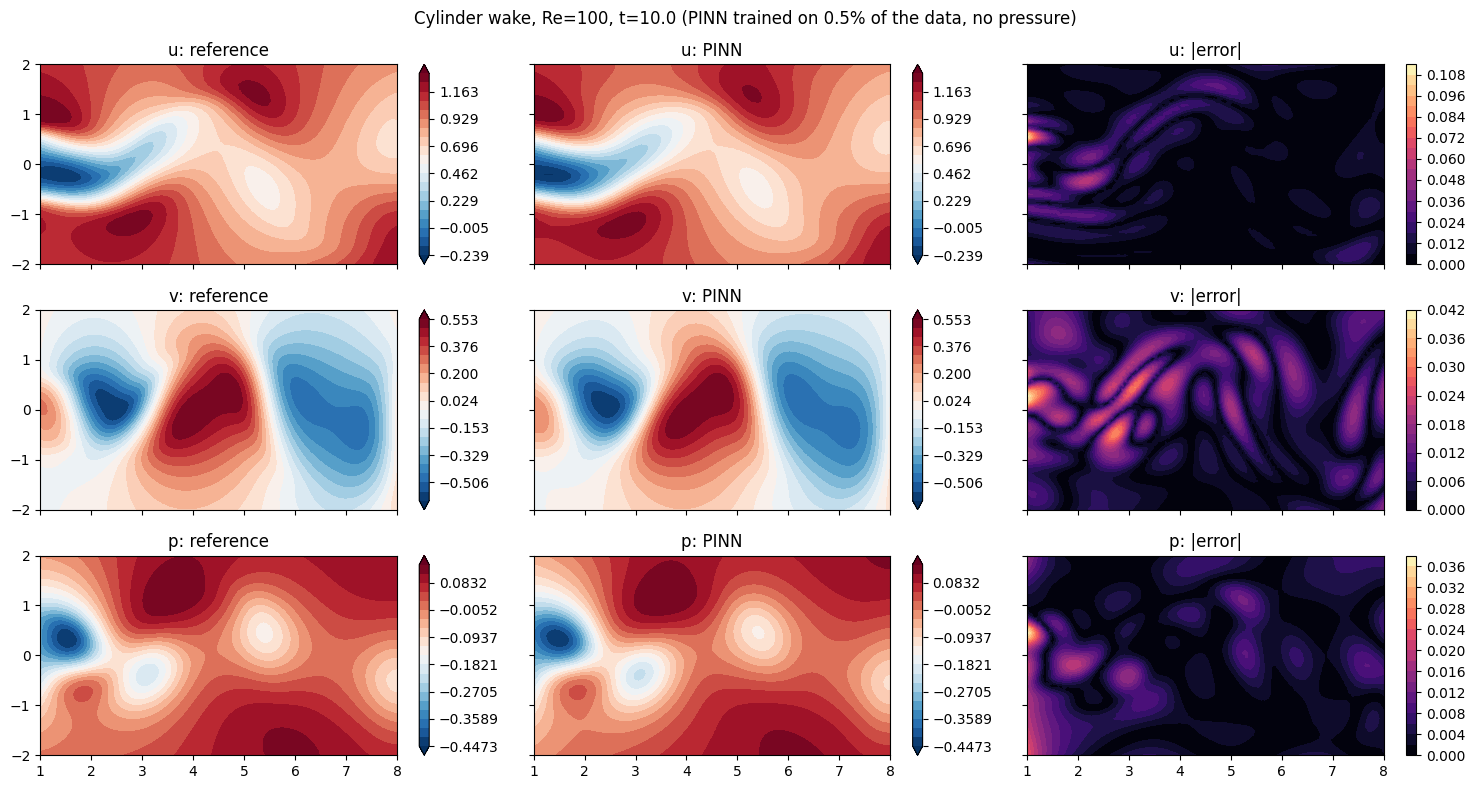

In [11]:
from matplotlib.tri import Triangulation
k = 100
xs, ys = to_t(X[:, 0:1]), to_t(X[:, 1:2]); ts = to_t(np.full((N, 1), t[k, 0]))
u, v, p, _, _ = fields(m64, xs, ys, ts)
u, v, p = [a.detach().cpu().numpy().ravel() for a in (u, v, p)]
ref  = {'u': U[:, 0, k], 'v': U[:, 1, k], 'p': P[:, k] - P[:, k].mean()}
pred = {'u': u, 'v': v, 'p': p - p.mean()}
tri = Triangulation(X[:, 0], X[:, 1])

fig, ax = plt.subplots(3, 3, figsize=(15, 8), sharex=True, sharey=True)
for i, n in enumerate('uvp'):
    lv = np.linspace(ref[n].min(), ref[n].max(), 21)
    for j, (f, ttl) in enumerate([(ref[n], 'reference'), (pred[n], 'PINN')]):
        c = ax[i, j].tricontourf(tri, f, levels=lv, cmap='RdBu_r', extend='both')
        ax[i, j].set_title(f'{n}: {ttl}')
        plt.colorbar(c, ax=ax[i, j])
    c = ax[i, 2].tricontourf(tri, np.abs(pred[n] - ref[n]), 20, cmap='magma')
    ax[i, 2].set_title(f'{n}: |error|'); plt.colorbar(c, ax=ax[i, 2])
    print(f'{n}: max abs err {np.abs(pred[n]-ref[n]).max():.3e}, rel L2 {rel_l2(pred[n], ref[n]):.4f}')
fig.suptitle(f'Cylinder wake, Re=100, t={t[k,0]:.1f} (PINN trained on 0.5% of the data, no pressure)')
plt.tight_layout(); plt.savefig('cylinder_fields.png', dpi=150); plt.show()

**Cell 11: parameter convergence**

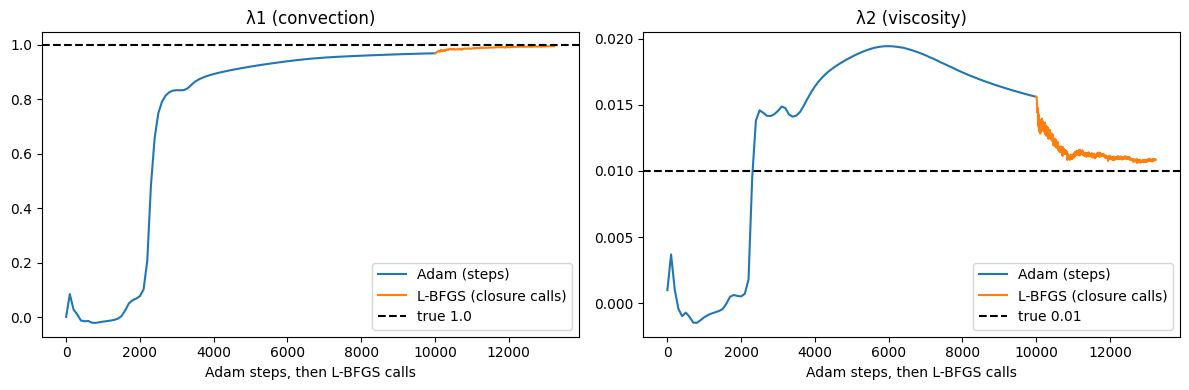

In [12]:
n_ad = len(hist['step'])
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, key, true, name in [(ax[0], 'lam1', 1.0, 'λ1 (convection)'), (ax[1], 'lam2', 0.01, 'λ2 (viscosity)')]:
    a.plot(hist['step'], hist[key], label='Adam (steps)')
    a.plot(10000 + np.arange(len(hist_lb[key])), hist_lb[key], label='L-BFGS (closure calls)')
    a.axhline(true, color='k', ls='--', label=f'true {true}')
    a.set_title(name); a.set_xlabel('Adam steps, then L-BFGS calls'); a.legend()
plt.tight_layout(); plt.savefig('cylinder_lambda.png', dpi=150); plt.show()

**Cell 12: more L-BFGS with a stopping rule**

In [13]:
prev = hist_lb['loss'][-1]
for r in range(4):
    opt_lb.step(closure)
    cur = hist_lb['loss'][-1]; gain = 1 - cur/prev; prev = cur
    print(f'--- extra round {r+1}: loss {cur:.3e}, gain {100*gain:.1f}%, '
          f'lam1 {m64.lam1.item():.4f}, lam2 {m64.lam2.item():.5f}')
    if gain < 0.10: break
torch.save(m64.state_dict(), 'pinn_cylinder_final.pt')
validate(m64)
print('lam1 err %.2f%%, lam2 err %.2f%%' %
      (100*abs(m64.lam1.item()-1), 100*abs(m64.lam2.item()-0.01)/0.01))

call 3301 loss 4.247e-04 data 1.747e-04 pde 2.500e-04 lam1 0.9952 lam2 0.01085
call 3401 loss 4.105e-04 data 1.673e-04 pde 2.431e-04 lam1 0.9951 lam2 0.01096
call 3501 loss 3.964e-04 data 1.607e-04 pde 2.357e-04 lam1 0.9958 lam2 0.01097
call 3601 loss 3.830e-04 data 1.545e-04 pde 2.285e-04 lam1 0.9961 lam2 0.01107
call 3701 loss 3.707e-04 data 1.496e-04 pde 2.212e-04 lam1 0.9959 lam2 0.01088
--- extra round 1: loss 3.613e-04, gain 16.7%, lam1 0.9959, lam2 0.01082
call 3801 loss 3.585e-04 data 1.422e-04 pde 2.164e-04 lam1 0.9964 lam2 0.01084
call 3901 loss 3.484e-04 data 1.397e-04 pde 2.086e-04 lam1 0.9953 lam2 0.01088
call 4001 loss 3.381e-04 data 1.355e-04 pde 2.026e-04 lam1 0.9961 lam2 0.01093
call 4101 loss 3.285e-04 data 1.323e-04 pde 1.962e-04 lam1 0.9959 lam2 0.01087
call 4201 loss 3.191e-04 data 1.265e-04 pde 1.926e-04 lam1 0.9958 lam2 0.01091
call 4301 loss 3.099e-04 data 1.214e-04 pde 1.885e-04 lam1 0.9963 lam2 0.01096
--- extra round 2: loss 3.080e-04, gain 14.7%, lam1 0.9960

**Cell 13: GIF and explainer figure**

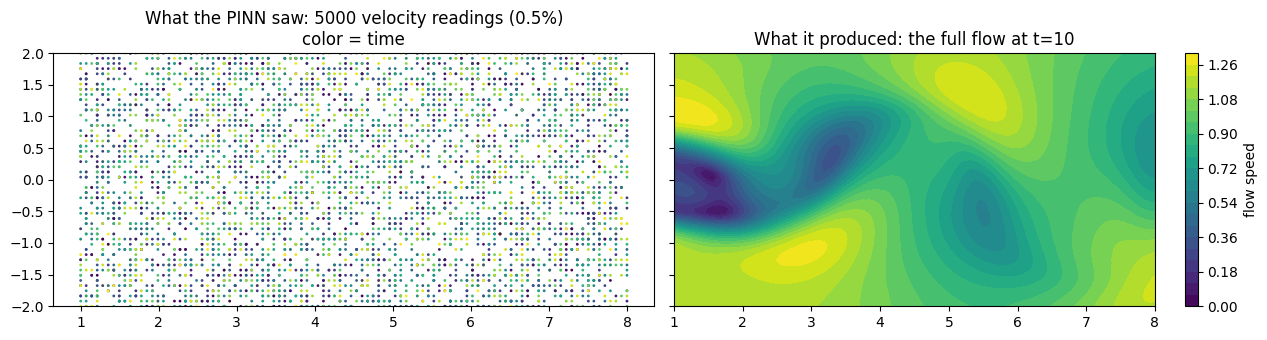

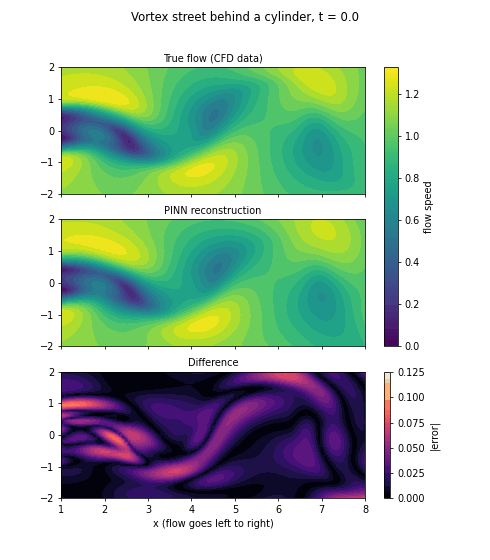

In [14]:
from matplotlib.animation import FuncAnimation, PillowWriter
import matplotlib as mpl

frames = list(range(0, 200, 2))                      # 100 frames
xs, ys = to_t(X[:, 0:1]), to_t(X[:, 1:2])
sp_ref, sp_pin = [], []
for k in frames:
    ts = to_t(np.full((N, 1), t[k, 0]))
    u, v, _, _, _ = fields(m64, xs, ys, ts)
    sp_pin.append(np.hypot(u.detach().cpu().numpy().ravel(), v.detach().cpu().numpy().ravel()))
    sp_ref.append(np.hypot(U[:, 0, k], U[:, 1, k]))
vmax = max(s.max() for s in sp_ref)
emax = max(np.abs(a - b).max() for a, b in zip(sp_pin, sp_ref))
lv_s, lv_e = np.linspace(0, vmax, 21), np.linspace(0, emax, 21)

fig, ax = plt.subplots(3, 1, figsize=(7, 8), sharex=True)
fig.colorbar(mpl.cm.ScalarMappable(mpl.colors.Normalize(0, vmax), 'viridis'), ax=ax[:2], label='flow speed')
fig.colorbar(mpl.cm.ScalarMappable(mpl.colors.Normalize(0, emax), 'magma'), ax=ax[2], label='|error|')

def draw(i):
    k = frames[i]
    for a, f, ttl, lv, cm in [(ax[0], sp_ref[i], 'True flow (CFD data)', lv_s, 'viridis'),
                              (ax[1], sp_pin[i], 'PINN reconstruction', lv_s, 'viridis'),
                              (ax[2], np.abs(sp_pin[i] - sp_ref[i]), 'Difference', lv_e, 'magma')]:
        a.clear(); a.tricontourf(tri, f, levels=lv, cmap=cm, extend='max'); a.set_title(ttl, fontsize=10)
    ax[2].set_xlabel('x (flow goes left to right)'); fig.suptitle(f'Vortex street behind a cylinder, t = {t[k,0]:.1f}')

anim = FuncAnimation(fig, draw, frames=len(frames))
anim.save('cylinder_wake.gif', writer=PillowWriter(fps=10), dpi=70)
plt.close(fig)

# Explainer: what the network saw vs what it produced
fig, ax = plt.subplots(1, 2, figsize=(13, 3.5), sharey=True)
ax[0].scatter(x_all[idx], y_all[idx], s=1, c=t_all[idx], cmap='viridis')
ax[0].set_title('What the PINN saw: 5000 velocity readings (0.5%)\ncolor = time')
k = 100; ts = to_t(np.full((N, 1), t[k, 0]))
u, v, _, _, _ = fields(m64, xs, ys, ts)
c = ax[1].tricontourf(tri, np.hypot(u.detach().cpu().numpy().ravel(), v.detach().cpu().numpy().ravel()), 21, cmap='viridis')
ax[1].set_title('What it produced: the full flow at t=10'); plt.colorbar(c, ax=ax[1], label='flow speed')
plt.tight_layout(); plt.savefig('cylinder_training_data.png', dpi=150); plt.show()
from IPython.display import Image; Image('cylinder_wake.gif')

---

**Future work (untested template)**

**Cell 14: bridge function**

In [15]:
import pandas as pd

def load_cfd_csv(path):
    """CSV columns: x,y,t,u,v  (export one row per point per time step).
    OpenFOAM: foamToVTK or a sample/probe export, then pandas.
    Fluent:   File > Export > Solution Data, ASCII, with x,y,velocity, one file per time step."""
    d = pd.read_csv(path)
    return [to_t(d[c].values.reshape(-1, 1)) for c in ('x', 'y', 't', 'u', 'v')]

# Dry run: write the Raissi data in the same format, read it back, check it matches
pd.DataFrame(dict(x=x_all[idx, 0], y=y_all[idx, 0], t=t_all[idx, 0],
                  u=u_all[idx, 0], v=v_all[idx, 0])).to_csv('demo_cfd.csv', index=False)
xc, yc, tc, uc, vc = load_cfd_csv('demo_cfd.csv')
print('rows', xc.shape[0], '| max |x diff|', (xc - x_tr).abs().max().item(),
      '| max |u diff|', (uc - u_tr).abs().max().item())

rows 5000 | max |x diff| 2.3601031085007662e-07 | max |u diff| 5.959525006815625e-08
